In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats.mstats import winsorize
from scipy.stats import chi2_contingency
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor


In [227]:
# data load
df = pd.read_csv('Data_Polis.csv')

print("Data Polis")
display(df.head()) 

print("\ndata info")
print(df.info())

# data load 2
df2 = pd.read_csv('Data_Klaim.csv')

print("\nData Klaim")
display(df2.head())

print("\ndata info")
print(df2.info())

Data Polis


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA
3,POL-0004,M-003,M,20140724,20160811,JAKARTA
4,POL-0005,M-001,F,19810114,20150828,JAKARTA



data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nomor Polis            4096 non-null   object
 1   Plan Code              4096 non-null   object
 2   Gender                 4096 non-null   object
 3   Tanggal Lahir          4096 non-null   int64 
 4   Tanggal Efektif Polis  4096 non-null   int64 
 5   Domisili               4096 non-null   object
dtypes: int64(2), object(4)
memory usage: 192.1+ KB
None

Data Klaim


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore



data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Claim ID                       4627 non-null   object 
 1   Nomor Polis                    4627 non-null   object 
 2   Reimburse/Cashless             4627 non-null   object 
 3   Inpatient/Outpatient           4590 non-null   object 
 4   ICD Diagnosis                  4621 non-null   object 
 5   ICD Description                4621 non-null   object 
 6   Status Klaim                   4627 non-null   object 
 7   Tanggal Pembayaran Klaim       4590 non-null   object 
 8   Tanggal Pasien Masuk RS        4627 non-null   object 
 9   Tanggal Pasien Keluar RS       4627 non-null   object 
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64
 11  Nominal Biaya RS Yang Terjadi  4627 non-null   float64
 12  Lokasi RS                      4620 n

In [228]:
df['Tanggal Lahir'] = pd.to_datetime(df['Tanggal Lahir'], format='%Y%m%d')
df['Tanggal Efektif Polis'] = pd.to_datetime(df['Tanggal Efektif Polis'], format='%Y%m%d')

df2['Tanggal Pembayaran Klaim'] = pd.to_datetime(df2['Tanggal Pembayaran Klaim'])
df2['Tanggal Pasien Masuk RS'] = pd.to_datetime(df2['Tanggal Pasien Masuk RS'])
df2['Tanggal Pasien Keluar RS'] = pd.to_datetime(df2['Tanggal Pasien Keluar RS'])

df.dtypes
df2.dtypes

Claim ID                                 object
Nomor Polis                              object
Reimburse/Cashless                       object
Inpatient/Outpatient                     object
ICD Diagnosis                            object
ICD Description                          object
Status Klaim                             object
Tanggal Pembayaran Klaim         datetime64[ns]
Tanggal Pasien Masuk RS          datetime64[ns]
Tanggal Pasien Keluar RS         datetime64[ns]
Nominal Klaim Yang Disetujui            float64
Nominal Biaya RS Yang Terjadi           float64
Lokasi RS                                object
dtype: object


Missing value Data Polis
Series([], dtype: int64)


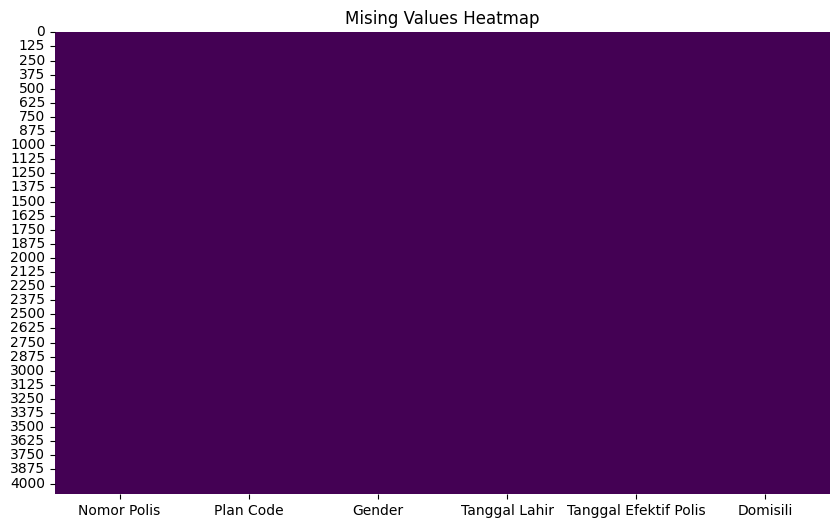


Missing value Data Klaim
Inpatient/Outpatient        37
ICD Diagnosis                6
ICD Description              6
Tanggal Pembayaran Klaim    37
Lokasi RS                    7
dtype: int64


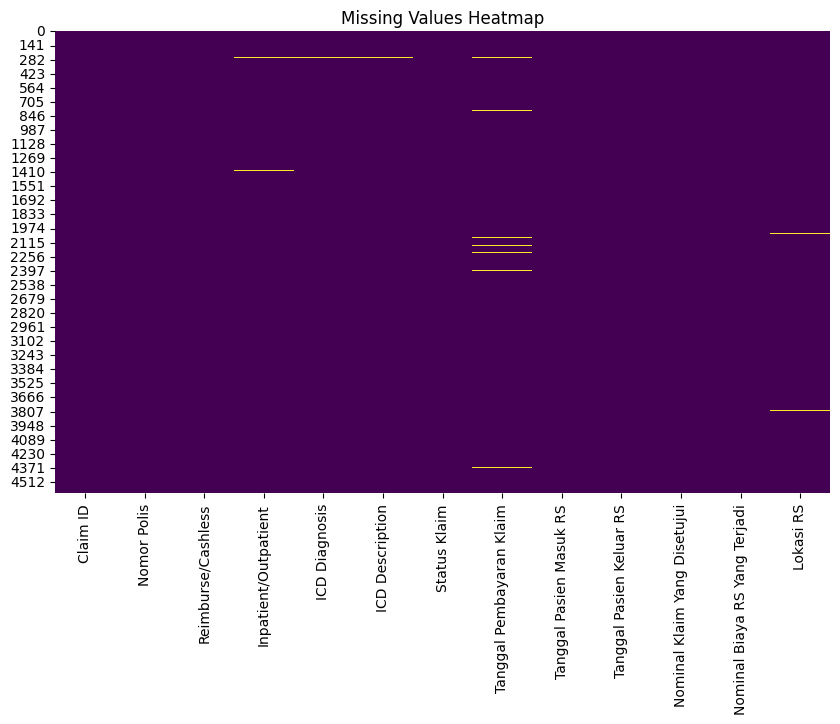

In [229]:
# missing value data polis
print("\nMissing value Data Polis")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mising Values Heatmap')
plt.show()

# missing value data klaim
print("\nMissing value Data Klaim")
missing_values = df2.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df2.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [230]:
df['Nomor Polis'] = df['Nomor Polis'].str.strip()
df2['Nomor Polis'] = df2['Nomor Polis'].str.strip()

df_final = pd.merge(df, df2, on='Nomor Polis', how='left')

print(f"Jumlah baris df_polis: {len(df)}")
print(f"Jumlah baris df_klaim: {len(df2)}")
print(f"Jumlah baris hasil merge: {len(df_final)}")

display(df_final.head())

Jumlah baris df_polis: 4096
Jumlah baris df_klaim: 4627
Jumlah baris hasil merge: 7513


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,POL-0001,M-003,M,1964-08-11,2014-06-03,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
1,POL-0002,M-003,M,1971-07-30,2014-06-03,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
2,POL-0003,M-001,M,1979-08-21,2016-08-08,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia
3,POL-0004,M-003,M,2014-07-24,2016-08-11,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
4,POL-0005,M-001,F,1981-01-14,2015-08-28,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN


In [231]:
cols_to_zero = ['Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi']
df_final[cols_to_zero] = df_final[cols_to_zero].fillna(0)

df_final['is_claim'] = df_final['Claim ID'].notnull().astype(int)

cat_cols = [
    'Claim ID', 'Reimburse/Cashless', 'Inpatient/Outpatient', 
    'ICD Diagnosis', 'ICD Description', 'Lokasi RS', 'Status Klaim'
]

for col in cat_cols:
    df_final.loc[df_final['is_claim'] == 0, col] = 'No Claim'
    df_final[col] = df_final[col].fillna('Unknown')

display(df_final.head())

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,is_claim
0,POL-0001,M-003,M,1964-08-11,2014-06-03,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
1,POL-0002,M-003,M,1971-07-30,2014-06-03,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
2,POL-0003,M-001,M,1979-08-21,2016-08-08,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia,1
3,POL-0004,M-003,M,2014-07-24,2016-08-11,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
4,POL-0005,M-001,F,1981-01-14,2015-08-28,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0


In [232]:
# Separasi Dataset
# Cluster Check untuk severity
cluster_check = df_final[df_final['Inpatient/Outpatient'].isnull() & df_final['Tanggal Pembayaran Klaim'].isnull()]
print(f"Jumlah baris dalam cluster masalah: {len(cluster_check)}")

# Dataset Severity (hanya klaim yang terjadi)
df_severity = df_final[df_final['is_claim'] == 1].copy()

# Bersihkan cluster 37 baris di data severity karena akan merusak akurasi fitur medis
df_severity = df_severity.dropna(subset=['Inpatient/Outpatient', 'ICD Diagnosis'])

# Dataset FREKUENSI 
df_frequency = df_final.copy()

print(f"Ukuran Data Severity: {df_severity.shape}")
print(f"Ukuran Data Frequency: {df_frequency.shape}")

Jumlah baris dalam cluster masalah: 0
Ukuran Data Severity: (4627, 19)
Ukuran Data Frequency: (7513, 19)


Baris sebelum drop usia negatif : 4627
Baris setelah drop usia negatif : 4627

Statistik Usia Severity:
count    4627.000000
mean       59.346490
std        12.567030
min         6.795346
25%        51.438741
50%        59.947981
75%        68.939083
max        90.324435
Name: Usia_Saat_Klaim, dtype: float64


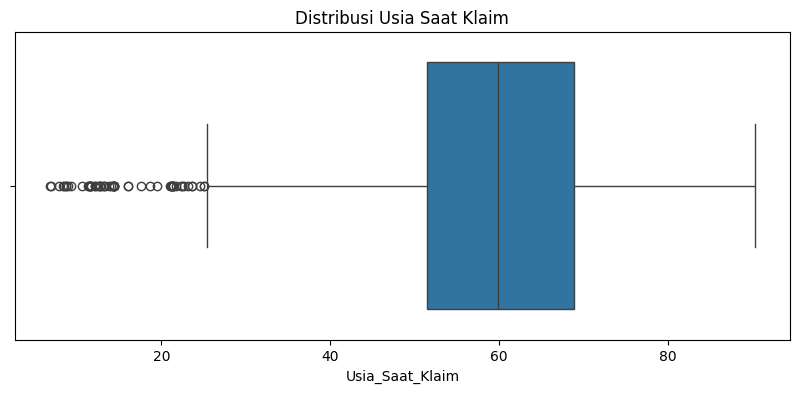

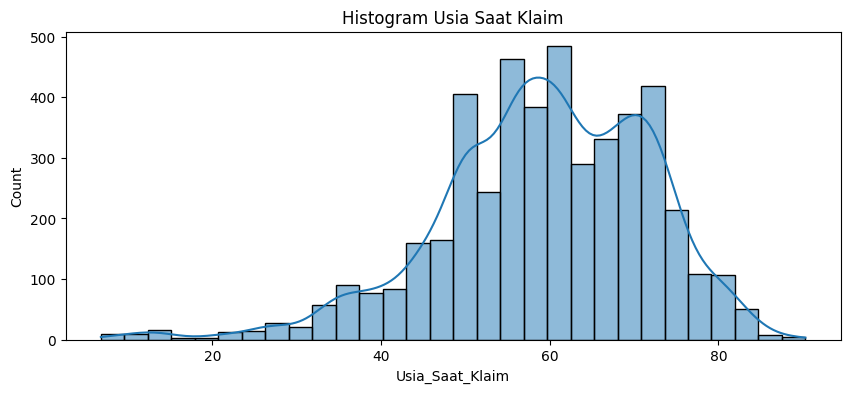

In [233]:
# Feature Engineering & Data Validation AGE)

# Hitung usia
df_severity['Usia_Saat_Klaim'] = (
    (df_severity['Tanggal Pasien Masuk RS'] - df_severity['Tanggal Lahir']).dt.days / 365.25
)

# handle usia negatif (data error)
before_rows = len(df_severity)
df_severity = df_severity[df_severity['Usia_Saat_Klaim'] >= 0].copy()
after_rows = len(df_severity)

print(f"Baris sebelum drop usia negatif : {before_rows}")
print(f"Baris setelah drop usia negatif : {after_rows}")

# Cap outlier biologis menggunakan batas logis 100 tahun
upper_cap = 100
outlier_count = (df_severity['Usia_Saat_Klaim'] > upper_cap).sum()

if outlier_count > 0:
    print(f"Ditemukan {outlier_count} usia > {upper_cap}. Akan di-cap.")
    df_severity.loc[
        df_severity['Usia_Saat_Klaim'] > upper_cap,
        'Usia_Saat_Klaim'
    ] = upper_cap

# BINNING USIA

age_bins = [0, 12, 18, 45, 65, 100]
age_labels = ['Anak', 'Remaja', 'Dewasa', 'Lansia_Awal', 'Lansia_Akhir']

df_severity['Kategori_Usia'] = pd.cut(
    df_severity['Usia_Saat_Klaim'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# USIA NASABAH (FREQUENCY)

ref_date = df_frequency['Tanggal Efektif Polis'].max()

df_frequency['Tanggal Lahir'] = pd.to_datetime(df_frequency['Tanggal Lahir'])

df_frequency['Usia_Nasabah'] = (
    (ref_date - df_frequency['Tanggal Lahir']).dt.days / 365.25
)

# Handle usia negatif 
df_frequency = df_frequency[df_frequency['Usia_Nasabah'] >= 0].copy()

# VISUALISASI
print("\nStatistik Usia Severity:")
print(df_severity['Usia_Saat_Klaim'].describe())

plt.figure(figsize=(10,4))
sns.boxplot(x=df_severity['Usia_Saat_Klaim'])
plt.title('Distribusi Usia Saat Klaim')
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(df_severity['Usia_Saat_Klaim'], bins=30, kde=True)
plt.title('Histogram Usia Saat Klaim')
plt.show()


In [234]:
# Hitung Length of Stay & Bersihkan Error

# Hitung LOS
df_severity['Lama_Inap'] = (
    df_severity['Tanggal Pasien Keluar RS'] -
    df_severity['Tanggal Pasien Masuk RS']
).dt.days

# Hapus error tanggal (keluar < masuk)
before_rows = len(df_severity)
df_severity = df_severity[df_severity['Lama_Inap'] >= 0].copy()
after_rows = len(df_severity)

print(f"Baris sebelum : {before_rows}")
print(f"Baris setelah : {after_rows}")

print(df_severity['Lama_Inap'].describe())

Baris sebelum : 4627
Baris setelah : 4627
count    4627.000000
mean        1.264102
std         2.930572
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        54.000000
Name: Lama_Inap, dtype: float64


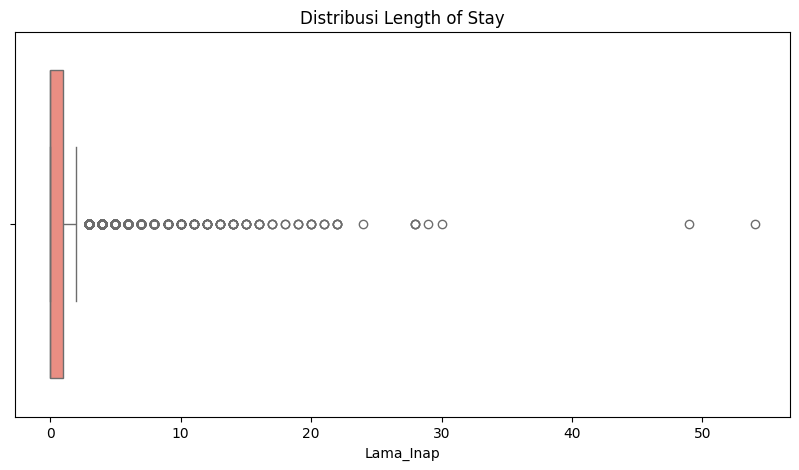

Detail LOS 54 Hari:


,Nomor Polis,ICD Description,Nominal Biaya RS Yang Terjadi,Inpatient/Outpatient
1368,POL-0830,"MALIGNANT NEOPLASM, BRONCHUS OR LUNG, UNSPECIFIED",1.465628e+09,IP


In [235]:
# Cek Outlier 54 Hari

plt.figure(figsize=(10,5))
sns.boxplot(x=df_severity['Lama_Inap'], color='salmon')
plt.title('Distribusi Length of Stay')
plt.show()

# Investigasi LOS 54 hari
outlier_54 = df_severity[df_severity['Lama_Inap'] == 54]

print("Detail LOS 54 Hari:")
display(outlier_54[['Nomor Polis',
                    'ICD Description',
                    'Nominal Biaya RS Yang Terjadi',
                    'Inpatient/Outpatient']])

In [236]:
# Feature Final LOS

# Dummy outpatient
df_severity['Is_Outpatient'] = (df_severity['Lama_Inap'] == 0).astype(int)

# Adjusted LOS (untuk hindari log(0))
df_severity['Lama_Inap_Adj'] = df_severity['Lama_Inap'] + 1

# Optional: Capping 99% (tidak akan menghapus 54 jika masih dalam batas)
los_cap = df_severity['Lama_Inap'].quantile(0.99)

df_severity['Lama_Inap_Capped'] = np.where(
    df_severity['Lama_Inap'] > los_cap,
    los_cap,
    df_severity['Lama_Inap']
)

print(f"99th percentile: {los_cap}")

print("\nStatistik Final:")
print(df_severity[['Lama_Inap','Lama_Inap_Capped']].describe())

99th percentile: 13.0

Statistik Final:
         Lama_Inap  Lama_Inap_Capped
count  4627.000000       4627.000000
mean      1.264102          1.192998
std       2.930572          2.401121
min       0.000000          0.000000
25%       0.000000          0.000000
50%       0.000000          0.000000
75%       1.000000          1.000000
max      54.000000         13.000000


In [237]:
# Feature Engineering (SEASONALITY) 

# 1 ENSURE DATETIME
df_severity['Tanggal Pasien Masuk RS'] = pd.to_datetime(
    df_severity['Tanggal Pasien Masuk RS']
)

# 2 BASIC TIME FEATURES
df_severity['Tahun_Masuk'] = df_severity['Tanggal Pasien Masuk RS'].dt.year
df_severity['Bulan_Masuk'] = df_severity['Tanggal Pasien Masuk RS'].dt.month
df_severity['Hari_Masuk'] = df_severity['Tanggal Pasien Masuk RS'].dt.dayofweek
df_severity['Tanggal'] = df_severity['Tanggal Pasien Masuk RS'].dt.day

# 3 PERIODE BULANAN 
df_severity['Periode_Klaim'] = (
    df_severity['Tanggal Pasien Masuk RS'].dt.to_period('M')
)

# 4 QUARTER FEATURE 
df_severity['Quarter'] = df_severity['Tanggal Pasien Masuk RS'].dt.quarter

# 5 WEEKEND FLAG 
df_severity['Is_Weekend'] = (
    df_severity['Hari_Masuk'].isin([5,6])
).astype(int)

# 6 CYCLICAL ENCODING BULAN 
df_severity['Bulan_sin'] = np.sin(
    2 * np.pi * df_severity['Bulan_Masuk'] / 12
)

df_severity['Bulan_cos'] = np.cos(
    2 * np.pi * df_severity['Bulan_Masuk'] / 12
)

# 7 VALIDASI 
print("Fitur seasonality berhasil dibuat.\n")

display(
    df_severity[[
        'Periode_Klaim',
        'Tahun_Masuk',
        'Bulan_Masuk',
        'Quarter',
        'Hari_Masuk',
        'Is_Weekend'
    ]].head()
)

Fitur seasonality berhasil dibuat.



,Periode_Klaim,Tahun_Masuk,Bulan_Masuk,Quarter,Hari_Masuk,Is_Weekend
2,2024-09,2024,9,3,0,0
5,2024-08,2024,8,3,4,0
6,2024-10,2024,10,4,2,0
10,2024-01,2024,1,1,4,0
11,2024-01,2024,1,1,3,0


In [238]:
# CELL REPORT: Claim Portfolio Summary 

# 1 Basic Metrics
total_claim = len(df_severity)
unique_policy_claim = df_severity['Nomor Polis'].nunique()
total_policy = df_frequency['Nomor Polis'].nunique()

avg_claim_per_policy = total_claim / unique_policy_claim

percentage_with_claim = (unique_policy_claim / total_policy) * 100
percentage_without_claim = ((total_policy - unique_policy_claim) / total_policy) * 100

# 2 DataFrame Report
df_claim_report = pd.DataFrame({
    'Total_Polis_Portfolio': [total_policy],
    'Total_Klaim': [total_claim],
    'Polis_Pernah_Klaim': [unique_policy_claim],
    'Polis_Tidak_Pernah_Klaim': [total_policy - unique_policy_claim],
    'Rata2_Klaim_per_Polis_Klaim': [round(avg_claim_per_policy, 2)],
    'Persentase_Polis_Pernah_Klaim (%)': [round(percentage_with_claim, 2)],
    'Persentase_Polis_Tidak_Klaim (%)': [round(percentage_without_claim, 2)]
})

display(df_claim_report)

,Total_Polis_Portfolio,Total_Klaim,Polis_Pernah_Klaim,Polis_Tidak_Pernah_Klaim,Rata2_Klaim_per_Polis_Klaim,Persentase_Polis_Pernah_Klaim (%),Persentase_Polis_Tidak_Klaim (%)
0,4096,4627,1210,2886,3.82,29.54,70.46


In [239]:
# ===============================
# 1. CLEAN COLUMN NAMES (SAFETY)
# ===============================
df_severity.columns = df_severity.columns.str.strip()

# ===============================
# 2. AGREGASI BULANAN
# ===============================
df_monthly = df_severity.groupby('Periode_Klaim').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal Klaim Yang Disetujui', 'sum'),
    Claim_Severity=('Nominal Klaim Yang Disetujui', 'mean')
).reset_index()

# Pastikan tipe datetime
df_monthly['Periode_Klaim'] = df_monthly['Periode_Klaim'].astype(str)
df_monthly['Periode_Klaim'] = pd.to_datetime(df_monthly['Periode_Klaim'])

df_monthly = df_monthly.sort_values('Periode_Klaim')

# ===============================
# 3. PADDING BULAN YANG HILANG
# ===============================
all_months = pd.date_range(
    start=df_monthly['Periode_Klaim'].min(),
    end=df_monthly['Periode_Klaim'].max(),
    freq='MS'
)

df_monthly = (
    df_monthly
    .set_index('Periode_Klaim')
    .reindex(all_months)
    .fillna(0)
    .rename_axis('Periode_Klaim')
    .reset_index()
)

# ===============================
# 4. TIME INDEX
# ===============================
df_monthly = df_monthly.sort_values('Periode_Klaim')
df_monthly['Time_Index'] = range(len(df_monthly))

# ===============================
# 5. LAG FEATURES
# ===============================
df_monthly['Freq_Lag_1'] = df_monthly['Claim_Frequency'].shift(1)
df_monthly['Freq_Lag_2'] = df_monthly['Claim_Frequency'].shift(2)

df_monthly['Sev_Lag_1'] = df_monthly['Claim_Severity'].shift(1)
df_monthly['Total_Lag_1'] = df_monthly['Total_Claim'].shift(1)

# Isi NaN hanya untuk lag (bukan semua kolom)
lag_cols = ['Freq_Lag_1', 'Freq_Lag_2', 'Sev_Lag_1', 'Total_Lag_1']
df_monthly[lag_cols] = df_monthly[lag_cols].fillna(0)

# ===============================
# 6. OPTIONAL (RECOMMENDED) ROLLING FEATURE
# ===============================
df_monthly['Freq_Rolling_3'] = df_monthly['Claim_Frequency'].rolling(3).mean().fillna(0)
df_monthly['Sev_Rolling_3'] = df_monthly['Claim_Severity'].rolling(3).mean().fillna(0)
df_monthly['Total_Rolling_3'] = df_monthly['Total_Claim'].rolling(3).mean().fillna(0)

# ===============================
# FINAL CHECK
# ===============================
print("Final shape:", df_monthly.shape)
display(df_monthly.head())

Final shape: (19, 12)


,Periode_Klaim,Claim_Frequency,Total_Claim,Claim_Severity,Time_Index,Freq_Lag_1,Freq_Lag_2,Sev_Lag_1,Total_Lag_1,Freq_Rolling_3,Sev_Rolling_3,Total_Rolling_3
0,2024-01-01,302,2.026098e+10,6.708934e+07,0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
1,2024-02-01,208,1.385965e+10,6.663291e+07,1,302.0,0.0,6.708934e+07,2.026098e+10,0.000000,0.000000e+00,0.000000e+00
2,2024-03-01,278,1.431126e+10,5.147935e+07,2,208.0,302.0,6.663291e+07,1.385965e+10,262.666667,6.173387e+07,1.614396e+10
3,2024-04-01,239,1.144106e+10,4.787056e+07,3,278.0,208.0,5.147935e+07,1.431126e+10,241.666667,5.532760e+07,1.320399e+10
4,2024-05-01,263,1.221146e+10,4.643141e+07,4,239.0,278.0,4.787056e+07,1.144106e+10,260.000000,4.859377e+07,1.265459e+10


In [240]:
print (df_monthly.head())

# Cek tanggal awal dan akhir di data bulanan
print("--- Rentang Waktu Data Bulanan ---")
print("Tanggal Terawal:", df_monthly['Periode_Klaim'].min())
print("Tanggal Terbaru:", df_monthly['Periode_Klaim'].max())

# Cek jumlah bulan yang tersedia
total_bulan = len(df_monthly)
print(f"Total Observasi: {total_bulan} bulan")

  Periode_Klaim  Claim_Frequency   Total_Claim  Claim_Severity  Time_Index  \
0    2024-01-01              302  2.026098e+10    6.708934e+07           0   
1    2024-02-01              208  1.385965e+10    6.663291e+07           1   
2    2024-03-01              278  1.431126e+10    5.147935e+07           2   
3    2024-04-01              239  1.144106e+10    4.787056e+07           3   
4    2024-05-01              263  1.221146e+10    4.643141e+07           4   

   Freq_Lag_1  Freq_Lag_2     Sev_Lag_1   Total_Lag_1  Freq_Rolling_3  \
0         0.0         0.0  0.000000e+00  0.000000e+00        0.000000   
1       302.0         0.0  6.708934e+07  2.026098e+10        0.000000   
2       208.0       302.0  6.663291e+07  1.385965e+10      262.666667   
3       278.0       208.0  5.147935e+07  1.431126e+10      241.666667   
4       239.0       278.0  4.787056e+07  1.144106e+10      260.000000   

   Sev_Rolling_3  Total_Rolling_3  
0   0.000000e+00     0.000000e+00  
1   0.000000e+00    

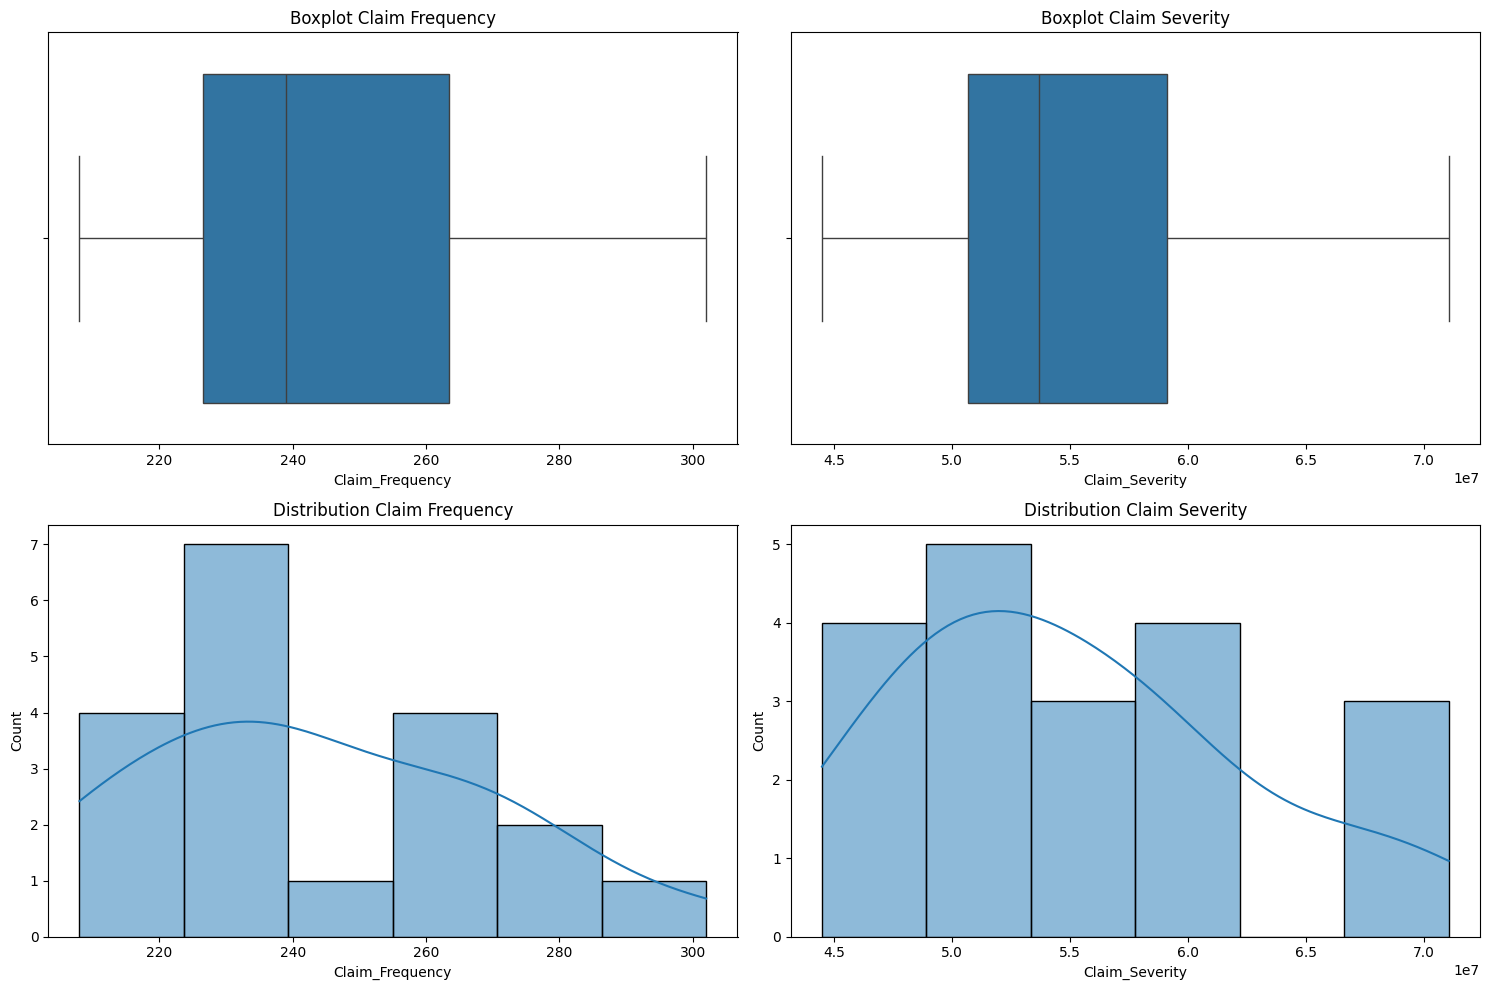

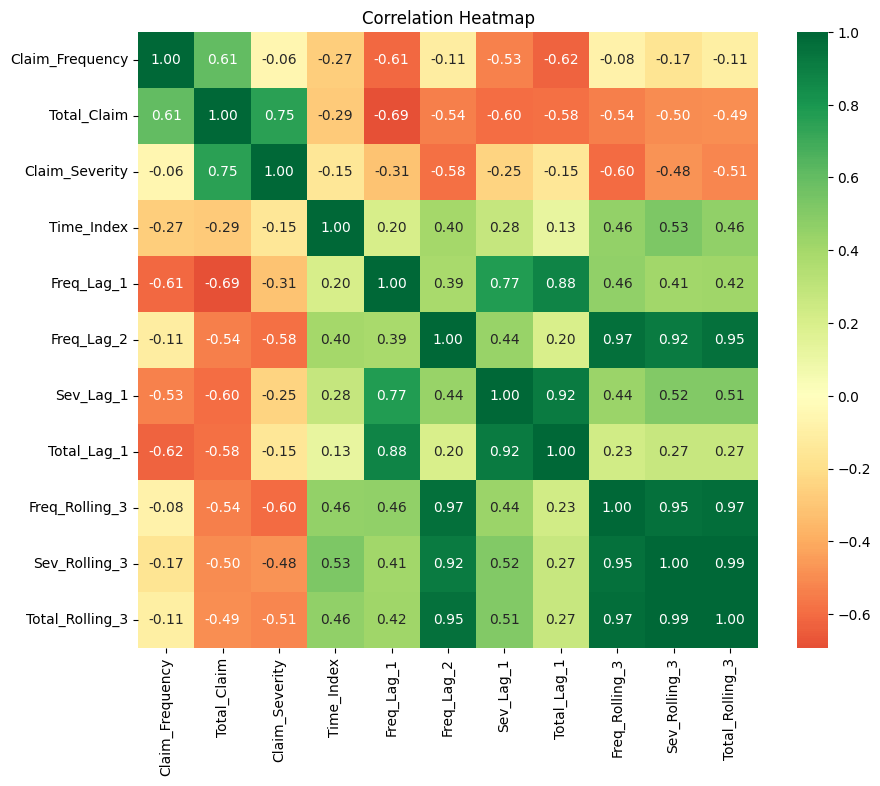

Total fitur siap modeling: 13


In [241]:
# Visual EDA
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(x=df_monthly['Claim_Frequency'], ax=ax[0,0])
ax[0,0].set_title('Boxplot Claim Frequency')

sns.boxplot(x=df_monthly['Claim_Severity'], ax=ax[0,1])
ax[0,1].set_title('Boxplot Claim Severity')

sns.histplot(df_monthly['Claim_Frequency'], kde=True, ax=ax[1,0])
ax[1,0].set_title('Distribution Claim Frequency')

sns.histplot(df_monthly['Claim_Severity'], kde=True, ax=ax[1,1])
ax[1,1].set_title('Distribution Claim Severity')

plt.tight_layout()
plt.show()

# Correlation
corr_matrix = df_monthly.drop(columns=['Periode_Klaim']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', center=0)
plt.title('Correlation Heatmap')
plt.show()

# LDA Feature Engineering
df_severity['Severity_Class'] = pd.qcut(
    df_severity['Nominal Klaim Yang Disetujui'],
    q=3,
    labels=[0, 1, 2]
)

lda_features = ['Usia_Saat_Klaim', 'Lama_Inap_Capped', 'Is_Weekend']
X_lda = df_severity[lda_features]
y_lda = df_severity['Severity_Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_lda)

lda = LinearDiscriminantAnalysis(n_components=2)
lda_values = lda.fit_transform(X_scaled, y_lda)

df_severity['Risk_Index_1'] = lda_values[:, 0]

lda_monthly = (
    df_severity
    .groupby('Periode_Klaim')['Risk_Index_1']
    .mean()
    .reset_index()
)

if str(lda_monthly['Periode_Klaim'].dtype).startswith('period'):
    lda_monthly['Periode_Klaim'] = lda_monthly['Periode_Klaim'].dt.to_timestamp()

df_monthly = df_monthly.merge(
    lda_monthly,
    on='Periode_Klaim',
    how='left'
).fillna(0)

print(f"Total fitur siap modeling: {df_monthly.shape[1]}")

In [242]:
# ==========================================
# SORTING
# ==========================================
df_monthly = df_monthly.sort_values('Periode_Klaim').reset_index(drop=True)

# ==========================================
# LAG FEATURES
# ==========================================
df_monthly['Freq_Lag_1'] = df_monthly['Claim_Frequency'].shift(1)
df_monthly['Freq_Lag_2'] = df_monthly['Claim_Frequency'].shift(2)

df_monthly['Sev_Lag_1'] = df_monthly['Claim_Severity'].shift(1)
df_monthly['Total_Lag_1'] = df_monthly['Total_Claim'].shift(1)

# ==========================================
# ROLLING (RETROSPEKTIF, NO LEAK)
# ==========================================
df_monthly['Freq_Rolling_3'] = (
    df_monthly['Claim_Frequency']
    .shift(1)
    .rolling(3)
    .mean()
)

df_monthly['Sev_Rolling_3'] = (
    df_monthly['Claim_Severity']
    .shift(1)
    .rolling(3)
    .mean()
)

df_monthly['Total_Rolling_3'] = (
    df_monthly['Total_Claim']
    .shift(1)
    .rolling(3)
    .mean()
)

# ==========================================
# RISK INDEX LAG (ANTI-LEAK)
# ==========================================
df_monthly['Risk_Index_Lag_1'] = df_monthly['Risk_Index_1'].shift(1)

# Fill hanya karena shift
df_monthly.fillna(0, inplace=True)

print("✅ Feature Engineering Leak-Free Selesai")

✅ Feature Engineering Leak-Free Selesai


In [243]:
# ==========================================
# SPLIT TIME SERIES
# ==========================================
split_index = 15

train = df_monthly.iloc[:split_index]
valid = df_monthly.iloc[split_index:]

print("Train Period:", train['Periode_Klaim'].min(), "s.d", train['Periode_Klaim'].max())
print("Valid Period:", valid['Periode_Klaim'].min(), "s.d", valid['Periode_Klaim'].max())

Train Period: 2024-01-01 00:00:00 s.d 2025-03-01 00:00:00
Valid Period: 2025-04-01 00:00:00 s.d 2025-07-01 00:00:00


In [244]:


# Endogenous
y_train = train['Claim_Frequency']
y_valid = valid['Claim_Frequency']

# Exogenous (pakai lag agar tidak bocor)
X_train_exog = train[['Risk_Index_Lag_1']]
X_valid_exog = valid[['Risk_Index_Lag_1']]

# Model XARIMA
model_xarima = SARIMAX(
    y_train,
    exog=X_train_exog,
    order=(1,0,1),   # stabil untuk 19 bulan
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_xarima = model_xarima.fit(disp=False)

# Forecast
forecast_xarima = results_xarima.forecast(
    steps=len(valid),
    exog=X_valid_exog
)

rmse_xarima = np.sqrt(mean_squared_error(y_valid, forecast_xarima))

print("RMSE XARIMA:", rmse_xarima)

RMSE XARIMA: 20.310726005825494


c:\Users\Ababil Khoerul Imam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [245]:

# Feature list
feature_cols = [
    'Freq_Lag_1',
    'Freq_Lag_2',
    'Sev_Lag_1',
    'Total_Lag_1',
    'Freq_Rolling_3',
    'Sev_Rolling_3',
    'Total_Rolling_3',
    'Time_Index',
    'Risk_Index_Lag_1'
]

X_train = train[feature_cols]
X_valid = valid[feature_cols]

y_train_xgb = train['Claim_Frequency']
y_valid_xgb = valid['Claim_Frequency']

# Model
model_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model_xgb.fit(X_train, y_train_xgb)

# Predict
pred_xgb = model_xgb.predict(X_valid)

rmse_xgb = np.sqrt(mean_squared_error(y_valid_xgb, pred_xgb))

print("RMSE XGBoost:", rmse_xgb)

RMSE XGBoost: 23.607267961073713


In [246]:
# =================================================================
# 1. RETRAIN & FORECAST (FULL 17 MONTHS: Aug 2025 - Dec 2026)
# =================================================================
# Retrain model XARIMA pada seluruh data (Jan 2024 - Jul 2025)
model_final = SARIMAX(
    df_monthly['Claim_Frequency'],
    exog=df_monthly[['Risk_Index_Lag_1']],
    order=(1,0,1),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(method='powell', maxiter=500, disp=False)

# Horizon: 17 bulan (5 bulan 2025 + 12 bulan 2026)
future_dates = pd.date_range(start='2025-08-01', periods=17, freq='MS')
future_exog = np.tile(df_monthly['Risk_Index_Lag_1'].mean(), (17, 1))

# Prediksi Frekuensi
forecast_freq = model_final.forecast(steps=17, exog=future_exog)
forecast_freq = np.maximum(forecast_freq, 0) # Safety net

# Setup Severitas (Asumsi: 2025 pakai rata-rata, 2026 baru kena inflasi 10%)
avg_sev_2025 = df_monthly['Claim_Severity'].mean()
medical_inflation_2026 = 1.10

# Gabungkan hasil ke DataFrame Master
df_master_forecast = pd.DataFrame({
    'Periode': future_dates,
    'Frequency': forecast_freq.values,
    'Severity': [avg_sev_2025 if d.year == 2025 else avg_sev_2025 * medical_inflation_2026 for d in future_dates]
})
df_master_forecast['Total_Claim'] = df_master_forecast['Frequency'] * df_master_forecast['Severity']

# =================================================================
# 2. MAPPING KE FORMAT SAMPLE SUBMISSION (AUG - DEC 2025)
# =================================================================
# Baca template submission
submission = pd.read_csv('sample_submission.csv')

# Loop untuk mengisi nilai berdasarkan ID (YYYY_MM_Metric)
for idx, row in df_master_forecast[df_master_forecast['Periode'].dt.year == 2025].iterrows():
    month_str = row['Periode'].strftime('%Y_%m')
    
    # Isi Frequency
    submission.loc[submission['id'] == f"{month_str}_Claim_Frequency", 'value'] = row['Frequency']
    # Isi Severity
    submission.loc[submission['id'] == f"{month_str}_Claim_Severity", 'value'] = row['Severity']
    # Isi Total Claim
    submission.loc[submission['id'] == f"{month_str}_Total_Claim", 'value'] = row['Total_Claim']

# Simpan hasil akhir untuk dikumpulkan ke Kaggle
submission.to_csv('final_submission_XARIMA.csv', index=False)
print("✅ File 'final_submission_XARIMA.csv' berhasil dibuat (Agustus-Desember 2025).")

# =================================================================
# 3. TAMPILAN UNTUK LAPORAN (DATA 2026)
# =================================================================
df_report_2026 = df_master_forecast[df_master_forecast['Periode'].dt.year == 2026].copy()
print("\n--- 📊 PROYEKSI STRATEGIS TAHUN 2026 ---")
display(df_report_2026.style.format({
    'Frequency': '{:.0f}', 
    'Severity': 'Rp{:,.0f}', 
    'Total_Claim': 'Rp{:,.0f}'
}))

✅ File 'final_submission_XARIMA.csv' berhasil dibuat (Agustus-Desember 2025).

--- 📊 PROYEKSI STRATEGIS TAHUN 2026 ---


C:\Users\Ababil Khoerul Imam\AppData\Local\Temp\ipykernel_13104\3159449000.py:44: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '235.81134512892856' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  submission.loc[submission['id'] == f"{month_str}_Claim_Frequency", 'value'] = row['Frequency']


,Periode,Frequency,Severity,Total_Claim
5,2026-01-01 00:00:00,234,"Rp60,580,885","Rp14,145,725,349"
6,2026-02-01 00:00:00,233,"Rp60,580,885","Rp14,117,903,368"
7,2026-03-01 00:00:00,233,"Rp60,580,885","Rp14,090,136,115"
8,2026-04-01 00:00:00,232,"Rp60,580,885","Rp14,062,423,480"
9,2026-05-01 00:00:00,232,"Rp60,580,885","Rp14,034,765,358"
10,2026-06-01 00:00:00,231,"Rp60,580,885","Rp14,007,161,640"
11,2026-07-01 00:00:00,231,"Rp60,580,885","Rp13,979,612,219"
12,2026-08-01 00:00:00,230,"Rp60,580,885","Rp13,952,116,989"
13,2026-09-01 00:00:00,230,"Rp60,580,885","Rp13,924,675,844"
14,2026-10-01 00:00:00,229,"Rp60,580,885","Rp13,897,288,676"
